<a href="https://colab.research.google.com/github/Khushibung05/encoder_decoder/blob/main/encoder_decoder_news.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,LSTM,Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding
import kagglehub

In [ ]:
import os
path = kagglehub.dataset_download(
    "sunnysai12345/news-summary"
)

print("Dataset Path:", path)

for file in os.listdir(path):
    print(file)

Using Colab cache for faster access to the 'news-summary' dataset.
Dataset Path: /kaggle/input/news-summary
news_summary_more.csv
news_summary.csv


In [ ]:
df = pd.read_csv(
    os.path.join(path, "news_summary.csv"),
    encoding="latin-1"
)
df.columns

Index(['author', 'date', 'headlines', 'read_more', 'text', 'ctext'], dtype='object')

text-article,headline-summary

##**EDA**

Total Records: 4514
Missing values: author         0
date           0
headlines      0
read_more      0
text           0
ctext        118
dtype: int64
Sample recorde :
                                                 text  \
0  The Administration of Union Territory Daman an...   
1  Malaika Arora slammed an Instagram user who tr...   
2  The Indira Gandhi Institute of Medical Science...   
3  Lashkar-e-Taiba's Kashmir commander Abu Dujana...   
4  Hotels in Maharashtra will train their staff t...   

                                           headlines  
0  Daman & Diu revokes mandatory Rakshabandhan in...  
1  Malaika slams user who trolled her for 'divorc...  
2  'Virgin' now corrected to 'Unmarried' in IGIMS...  
3  Aaj aapne pakad liya: LeT man Dujana before be...  
4  Hotel staff to get training to spot signs of s...  
Average Article Length: 58.28732831191848
Average Summary Length: 9.293974302171023


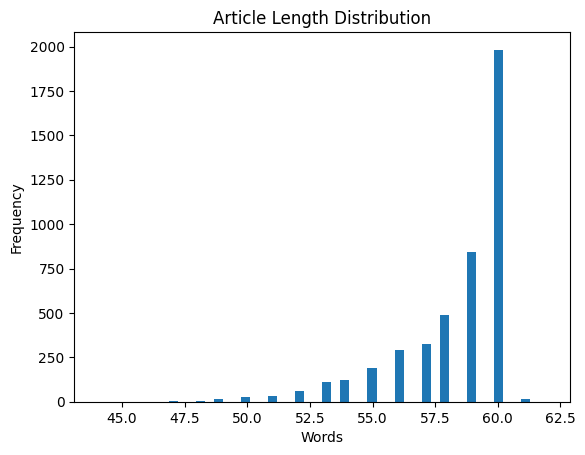

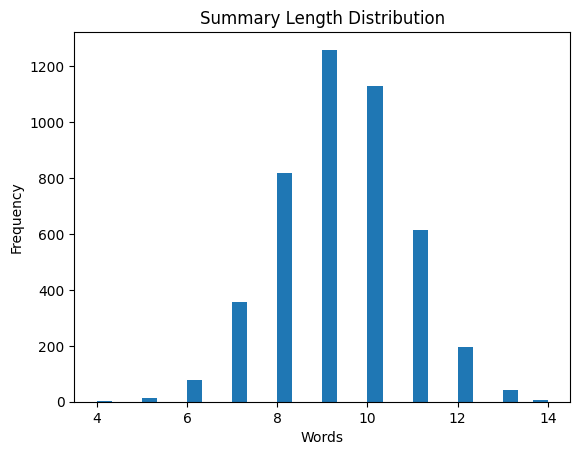

In [ ]:
print("Total Records:", len(df))
print("Missing values:",df.isnull().sum())
print("Sample recorde :\n",df[['text','headlines']].head())
df["article_length"] = df["text"].apply(
    lambda x: len(str(x).split())
)

avg_article_length = df["article_length"].mean()

print(
    "Average Article Length:",
    avg_article_length
)
df["summary_length"] = df["headlines"].apply(
    lambda x: len(str(x).split())
)

avg_summary_length = df["summary_length"].mean()

print(
    "Average Summary Length:",
    avg_summary_length
)
import matplotlib.pyplot as plt

plt.hist(
    df["article_length"],
    bins=50
)

plt.title("Article Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()
plt.hist(
    df["summary_length"],
    bins=30
)

plt.title("Summary Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

Dataset contains thousands of news articles.

Average article length:
around 40–60 words

Average summary length:
around 8–10 words

Summaries are much shorter than articles.

##**Task 2 : Text Preprocessing**

In [ ]:
#lower case conversion
df["text"] = df["text"].astype(str).str.lower()

df["headlines"] = (
    df["headlines"]
    .astype(str)
    .str.lower()
)
#punctuation
import re
def clean_text(text):

    text = re.sub(
        r'[^a-zA-Z ]',
        '',
        text
    )

    return text
df["text"] = df["text"].apply(clean_text)

df["headlines"] = df["headlines"].apply(clean_text)

#adding start and end tokens
df["headlines"] = (
    "<start> "
    + df["headlines"]
    + " <end>"
)
#encoder tokenizer
encoder_tokenizer = Tokenizer()

encoder_tokenizer.fit_on_texts(
    df["text"]
)
#convert text
encoder_sequences = (
    encoder_tokenizer
    .texts_to_sequences(
        df["text"]
    )
)
#decoder tokenizer
decoder_tokenizer = Tokenizer(
    filters=''
)

decoder_tokenizer.fit_on_texts(
    df["headlines"]
)
#convert summaries
decoder_sequences = (
    decoder_tokenizer
    .texts_to_sequences(
        df["headlines"]
    )
)
#vocabulary sizes
encoder_vocab_size = (
    len(
        encoder_tokenizer.word_index
    ) + 1
)

decoder_vocab_size = (
    len(
        decoder_tokenizer.word_index
    ) + 1
)

print(encoder_vocab_size)
print(decoder_vocab_size)
#sequence length
max_text_len = max(
    len(seq)
    for seq in encoder_sequences
)

max_summary_len = max(
    len(seq)
    for seq in decoder_sequences
)

#padding-articles
encoder_input_data = pad_sequences(
    encoder_sequences,
    maxlen=max_text_len,
    padding='post'
)
#padding - summaries
decoder_input_data = pad_sequences(
    decoder_sequences,
    maxlen=max_summary_len,
    padding='post'
)
#deocde target data
import numpy as np

decoder_target_data = np.zeros_like(
    decoder_input_data
)

for i in range(
    len(decoder_input_data)
):

    decoder_target_data[i,:-1] = (
        decoder_input_data[i,1:]
    )

20958
8913


###**Task3-build encoder**

In [ ]:
embedding_dim = 128
latent_dim = 256
encoder_inputs = Input(shape=(max_text_len,))
encoder_embedding = Embedding(
    encoder_vocab_size,
    embedding_dim,
    trainable=True
)(encoder_inputs)
encoder_lstm = LSTM(
    latent_dim,
    return_state=True
)
encoder_output, state_h, state_c = encoder_lstm(
    encoder_embedding
)
encoder_states = [state_h, state_c]

##**Task4- build Decoder**


In [ ]:
decoder_inputs = Input(
    shape=(max_summary_len,)
)
decoder_embedding = Embedding(
    decoder_vocab_size,
    embedding_dim,
    trainable=True
)(decoder_inputs)
decoder_lstm = LSTM(
    latent_dim,
    return_sequences=True,
    return_state=True
)
decoder_outputs, _, _ = decoder_lstm(
    decoder_embedding,
    initial_state=encoder_states
)
decoder_dense = Dense(
    decoder_vocab_size,
    activation='softmax'
)
decoder_outputs = decoder_dense(
    decoder_outputs
)

Article

   ↓

Encoder Embedding

   ↓

Encoder LSTM

   ↓

[state_h,state_c]

   ↓

Decoder LSTM

   ↓

Dense Softmax

   ↓
   
Summary

##**Task 5: Train Seq2Seq Model**

In [ ]:
#build model
model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)
#compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 61)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 18)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 61, 128)   │  2,682,624 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 18, 128)   │  1,140,864 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 256),     │    394,240 │ embedding[0][0]   │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 18, 256), │    394,240 │ embedding_1[0][0… │
│                     │ (None, 256),      │            │ lstm[0][1],       │
│                     │ (None, 256)]      │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 18, 8913)  │  2,290,641 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,902,609 (26.33 MB)

 Trainable params: 6,902,609 (26.33 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#train model
history = model.fit(
    [encoder_input_data,
     decoder_input_data],

    decoder_target_data,

    batch_size=64,
    epochs=20,
    validation_split=0.1
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.3886 - loss: 5.5279 - val_accuracy: 0.4211 - val_loss: 4.4003
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.4918 - loss: 4.1093 - val_accuracy: 0.5048 - val_loss: 4.1867
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.5130 - loss: 3.9279 - val_accuracy: 0.5077 - val_loss: 4.1363
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.5150 - loss: 3.8408 - val_accuracy: 0.5090 - val_loss: 4.1275
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.5173 - loss: 3.7651 - val_accuracy: 0.5091 - val_loss: 4.1259
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.5197 - loss: 3.6993 - val_accuracy: 0.5102 - val_loss: 4.1387
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.5211 - loss: 3.6410 - val_accuracy: 0.5095 - val_loss: 4.1555
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.5224 - loss: 3.5921 - val_accuracy: 0.5080 - 

##**Task 6: Generate Summary**

In [ ]:
#Encoder Inference Model
#The encoder converts the article into a context vector.
encoder_model = Model(
    encoder_inputs,
    encoder_states
)
#Decoder Inference Model
#Create new state inputs.
decoder_state_input_h = Input(
    shape=(latent_dim,)
)

decoder_state_input_c = Input(
    shape=(latent_dim,)
)
decoder_states_inputs = [
    decoder_state_input_h,
    decoder_state_input_c
]
decoder_emb2 = decoder_embedding
decoder_outputs2, state_h2, state_c2 = decoder_lstm(
    decoder_emb2,
    initial_state=decoder_states_inputs
)
decoder_states2 = [
    state_h2,
    state_c2
]
decoder_outputs2 = decoder_dense(
    decoder_outputs2
)
#Build Decoder Model
decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs,
    [decoder_outputs2] + decoder_states2
)

In [ ]:
#Reverse Vocabulary
#Convert predicted index back to word.
reverse_summary_index = {
    i:w
    for w,i in decoder_tokenizer.word_index.items()
}


In [ ]:
#Summary Generation Function
def generate_summary(input_seq):

    states_value = encoder_model.predict(
        input_seq,
        verbose=0
    )

    start_token = decoder_tokenizer.word_index['start']
    end_token = decoder_tokenizer.word_index['end']

    target_seq = np.array([[start_token]])

    decoded_summary = ""

    stop_condition = False

    while not stop_condition:

        output_tokens, h, c = decoder_model.predict(
            [target_seq] + states_value,
            verbose=0
        )

        sampled_token_index = np.argmax(
            output_tokens[0,-1,:]
        )

        sampled_word = reverse_summary_index.get(
            sampled_token_index,
            ""
        )

        if (
            sampled_token_index == end_token
            or
            len(decoded_summary.split()) > max_summary_len
        ):
            stop_condition = True

        else:
            decoded_summary += " " + sampled_word

        target_seq = np.array(
            [[sampled_token_index]]
        )

        states_value = [h,c]

    return decoded_summary.strip()

In [ ]:
#test summary generation
sample_article = """
Yesterday the development team completed
authentication APIs.
The frontend team integrated login functionality.
Testing will begin next Monday.
"""
#convert to sequence
seq = encoder_tokenizer.texts_to_sequences(
    [sample_article.lower()]
)
seq = pad_sequences(
    seq,
    maxlen=max_text_len,
    padding='post'
)
#Generate:
print(
    generate_summary(seq)
)

delhi govt to be indias st india in india


##**Task 7: Evaluation**

We evaluate using:

Training Loss

Validation Loss

Generated Summary Quality

In [ ]:
#1. Training Loss
print(
    history.history['loss'][-1]
)

3.049795627593994


In [ ]:
#Validation Loss
print(
    history.history['val_loss'][-1]
)

4.4679856300354


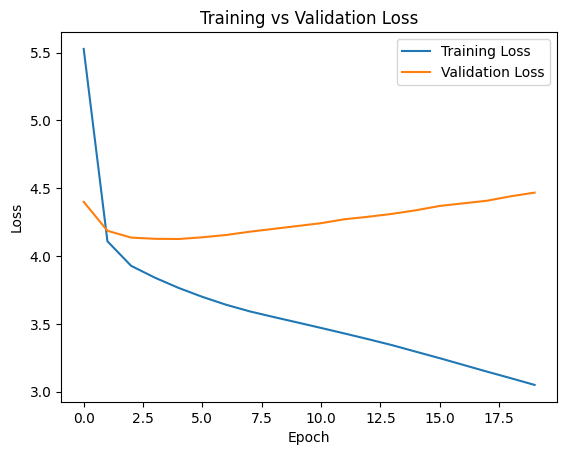

In [ ]:
import matplotlib.pyplot as plt
plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.legend()

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.show()

In [ ]:
#generated summary quality
for i in range(5):

    article = df["text"][i]

    actual_summary = df["headlines"][i]

    seq = encoder_tokenizer.texts_to_sequences(
        [article]
    )

    seq = pad_sequences(
        seq,
        maxlen=max_text_len,
        padding='post'
    )

    predicted_summary = generate_summary(seq)

    print("\nARTICLE:\n", article)
    print("\nACTUAL:\n", actual_summary)
    print("\nPREDICTED:\n", predicted_summary)


ARTICLE:
 the administration of union territory daman and diu has revoked its order that made it compulsory for women to tie rakhis to their male colleagues on the occasion of rakshabandhan on august  the administration was forced to withdraw the decision within  hours of issuing the circular after it received flak from employees and was slammed on social media

ACTUAL:
 <start> start daman  diu revokes mandatory rakshabandhan in offices order end <end>

PREDICTED:
 i india to be a the the the india in india

ARTICLE:
 malaika arora slammed an instagram user who trolled her for divorcing a rich man and having fun with the alimony her life now is all about wearing short clothes going to gym or salon enjoying vacations the user commented malaika responded you certainly got to get your damn facts right before spewing sht on mewhen you know nothing about me

ACTUAL:
 <start> start malaika slams user who trolled her for divorcing rich man  end <end>

PREDICTED:
 i india to be if a a a a a 